# GFN Non-Acyclic Baseline Diagnostics (Standalone)

ULA baseline diagnostics with targets from `targets/` (same names and defaults as `configs/target/*.yaml`). **ULA figure**: **multi-γ overlay** (or a single γ): mean curve ± 95% band **across eval seeds** per γ; **RG** / **Geweke** markers with **x/y error bars** (2.5–97.5% across seeds). Metrics at stops use the **full parallel batch** per seed. No Hydra.

In [1]:
import os
import sys
from pathlib import Path

# Repo root on sys.path so `import targets` works when the kernel cwd is `notebooks/`.
for _root in (Path.cwd(), Path.cwd().parent):
    if (_root / "targets").is_dir():
        sys.path.insert(0, str(_root.resolve()))
        break

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

from dataclasses import dataclass, field
import distrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from eval.discrepancies import compute_sd
from algorithms.gfn_non_acyclic.mcmc_diagnostics import compute_geweke_z

In [2]:
@dataclass
class EarlyStopRhat:
    threshold: float = 1.1


@dataclass
class EarlyStopGeweke:
    frac1: float = 0.1
    frac2: float = 0.5
    spectral_estimator: str = "ar"
    max_abs_z_threshold: float = 4.0


@dataclass
class EarlyStopCfg:
    min_chain_length: int = 20
    n_checkpoints: int = 5
    rhat: EarlyStopRhat = field(default_factory=EarlyStopRhat)
    geweke: EarlyStopGeweke = field(default_factory=EarlyStopGeweke)


@dataclass
class ModelCfg:
    gamma: float = 0.1

@dataclass
class AlgorithmCfg:
    name: str = "gfn_non_acyclic_baseline_diagnostics"
    batch_size: int = 2000
    eval_max_steps: int = 10000
    step_name: str = "ula"
    init_std: float = 1.0
    model: ModelCfg = field(default_factory=ModelCfg)
    gammas: list = field(default_factory=lambda: [0.05, 0.1, 0.5])
    n_eval_seeds: int = 3
    compute_mmd: bool = True
    early_stop: EarlyStopCfg = field(default_factory=EarlyStopCfg)

@dataclass
class Config:
    seed: int = 0
    eval_samples: int = 2048
    algorithm: AlgorithmCfg = field(default_factory=AlgorithmCfg)

cfg = Config()

In [8]:
from targets.funnel import Funnel
from targets.gmm9 import GMM9
from targets.many_well import ManyWellEnergy
from functools import partial

from algorithms.gfn_non_acyclic.gfn_non_acyclic_rnd import rnd_mcmc
import jax

# (mtl, metric) reference points from `configs/target/*.yaml` → `reference_metrics` (dim_* blocks).
# Same semantics as `gfn_non_acyclic_baseline_diagnostics._plot_metric_curves_overlay` (purple / red dots).
REFERENCE_METRICS = {
    # ("funnel", 2): {
    #     "ula_clf": {"mtl": 21.84, "mmd": 0.12, "sd": 8.84},
    #     "full_model": {"mtl": 36.33, "mmd": 0.08, "sd": 4.94},
    # },
    ("gaussian_mixture9", 2): {
        "ula_clf": {"mtl": 15.01, "mmd": 0.05, "sd": 1.52},
        "full_model": {"mtl": 29.59, "mmd": 0.02, "sd": 0.22},
    },
    # ("gaussian_mixture9", 40): {
    #     "full_model": {"mtl": 27.83, "mmd": 0.25, "sd": 243.80},
    # },
    # ("many_well", 40): {
    #     "full_model": {"mtl": 75.38, "mmd": 0.31, "sd": 62.47},
    # },
}

# (name, dim, gammas). All entries in `gammas` are overlaid in one figure.
TARGET_GRID = [
    # ("funnel", 2, [0.05]),
    ("gaussian_mixture9", 2, [1.0, 0.1, 0.01]),
    # ("many_well", 40, [0.05, 0.01, 0.005]),
]
ACTIVE_IDX = 0


def make_target(name: str, dim: int):
    """Construct targets with defaults matching `configs/target/{name}.yaml` `fn` blocks."""
    if name == "funnel":
        return Funnel(dim=dim, log_Z=0.0, can_sample=True, sample_bounds=(-30.0, 30.0))
    if name == "gaussian_mixture9":
        return GMM9(
            dim=dim,
            num_components=9,
            loc_scaling=40.0,
            scale_scaling=1.0,
            seed=0,
            sample_bounds=None,
            can_sample=True,
            log_Z=0,
        )
    if name == "many_well":
        return ManyWellEnergy(
            dim=dim, a=-0.5, b=-6.0, c=1.0, can_sample=True, sample_bounds=None
        )
    raise ValueError(f"Unknown target {name!r}; expected funnel, gaussian_mixture9, many_well")

# JIT-compiled wrapper for rnd_mcmc, matching expected notebook arg order

@partial(jax.jit, static_argnums=(1,2,3,4,5,6))
def rnd_mcmc_standalone(key, batch_size, aux_tuple, target, num_steps, step_name, initial_dist):
    """
    Use algorithms.gfn_non_acyclic.gfn_non_acyclic_rnd.rnd_mcmc for ULA, under JIT.
    """
    if step_name != "ula":
        raise ValueError("This notebook only implements step_name='ula'.")
    gamma = float(aux_tuple[0])
    return rnd_mcmc(key, model_state=None, params=None, batch_size=batch_size, aux_tuple=aux_tuple, target=target, num_steps=num_steps, step_name="ula", initial_dist=initial_dist)

_name, _dim, _gammas = TARGET_GRID[ACTIVE_IDX]
cfg.algorithm.gammas = list(_gammas)
target = make_target(_name, _dim)
print(f"target={_name} dim={target.dim} gammas={cfg.algorithm.gammas}")

target=gaussian_mixture9 dim=2 gammas=[1.0, 0.1, 0.01]


In [9]:
def compute_mmd(reference, samples, sigma=1.0):
    # Make inputs jnp.arrays for JIT-compatibility, assume (N, D) shapes
    reference = jnp.asarray(reference)
    samples = jnp.asarray(samples)
    sigma = jnp.asarray(sigma)

    def rbf(x, y, sigma):
        sq = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)
        return jnp.exp(-sq / (2 * sigma ** 2))

    return (
        jnp.mean(rbf(reference, reference, sigma))
        + jnp.mean(rbf(samples, samples, sigma))
        - 2 * jnp.mean(rbf(reference, samples, sigma))
    )


# Classical multivariate R-hat max over coords (same kernel as `gfn_non_acyclic_baseline_diagnostics`).
_DIAG_EPS = 1e-12

@jax.jit
def _psrf_with_chain_masks_jax(x, chain_masks):
    # x: (chains, steps, dim), chain_masks: (chains, steps) bool
    m = x.shape[0]
    mask_f = chain_masks.astype(jnp.float32)[:, :, None]
    n_eff = jnp.sum(mask_f, axis=1)   # (chains, 1)
    n_eff_safe = jnp.maximum(n_eff, 1.0)
    means = jnp.sum(x * mask_f, axis=1) / n_eff_safe  # (chains, dim)
    centered = (x - means[:, None, :]) * mask_f
    vars_ = jnp.sum(centered * centered, axis=1) / jnp.maximum(n_eff - 1.0, 1.0)  # (chains, dim)
    w = jnp.mean(vars_, axis=0)  # (dim,)
    overall = jnp.mean(means, axis=0)  # (dim,)
    n_bar = jnp.maximum(jnp.mean(n_eff), 1.0)
    b = n_bar * jnp.sum((means - overall[None, :]) ** 2, axis=0) / jnp.maximum(m - 1, 1)
    vhat = ((n_bar - 1.0) / n_bar) * w + b / n_bar
    rhat = jnp.sqrt(jnp.maximum(vhat, _DIAG_EPS) / jnp.maximum(w, _DIAG_EPS))
    valid_chain = jnp.all(n_eff[:, 0] >= 2.0)
    valid = jnp.logical_and(m >= 2, valid_chain)
    return jnp.where(valid, rhat, jnp.full_like(rhat, jnp.inf))


@jax.jit
def _rhat_classical_point_jax(traj, t):
    """
    Accepts JAX arrays, compatible with jitted mcmc. 
    traj: (chains, max_steps, dim)
    t: integer step index
    """
    c, n, _ = traj.shape
    step_idx = jnp.arange(n)
    active = step_idx < t
    active_cn = jnp.broadcast_to(active[None, :], (c, n))
    classical_vec = _psrf_with_chain_masks_jax(traj, active_cn)
    return jnp.max(classical_vec)

In [12]:
def _build_t_grid(max_steps: int, min_steps: int, n_points: int):
    grid = np.linspace(min_steps, max_steps, num=n_points, dtype=int)
    grid = np.clip(grid, min_steps, max_steps)
    return np.unique(grid)


def _metric_scalar(name, target_xs, samples, cfg):
    """Single SD/MMD on full `samples` (batch, dim) vs `target_xs`. SD matches `eval.discrepancies.compute_sd`."""
    if name == "sd":
        return float(compute_sd(target_xs, samples, cfg))
    return float(compute_mmd(target_xs, samples))


def _geweke_stop_t_per_chain(traj_np, t_grid, gw):
    B, T, d = traj_np.shape
    stop_t = np.full(B, -1, dtype=int)
    for t in t_grid:
        t = int(t)
        if t < 3 or t > T:
            continue
        try:
            z = compute_geweke_z(
                traj_np[:, :t, :],
                frac1=gw.frac1,
                frac2=gw.frac2,
                estimator=gw.spectral_estimator,
            )
        except ValueError:
            continue
        max_abs = np.max(np.abs(z), axis=1)
        newly = (stop_t == -1) & (max_abs <= gw.max_abs_z_threshold)
        stop_t[newly] = t
    return stop_t


def run_ula_dashboard_for_gamma(cfg, target, gamma, key):
    """
    ULA curves + RG / Geweke for one step size γ; 
    CIs from `n_eval_seeds` only. Returns `(data, new_key)`.

    Fixes JAX abstract array error by making sure that rnd_mcmc_standalone
    is called with static arguments correctly, avoiding passing partials or objects unless using static_argnums in a jit wrapper.
    """

    alg = cfg.algorithm
    gamma = float(gamma)
    es = alg.early_stop
    target_xs = target.sample(jax.random.PRNGKey(0), (cfg.eval_samples,))
    init = distrax.MultivariateNormalDiag(
        jnp.zeros(target.dim), jnp.ones(target.dim) * alg.init_std
    )
    t_grid = _build_t_grid(alg.eval_max_steps, es.min_chain_length, es.n_checkpoints)

    # We assume rnd_mcmc_standalone is defined/jitted with static_argnames/static_argnums for non-array arguments
    # We do NOT pass non-array objects using functools.partial as an argument.
    # Instead, call directly with correct positional and keyword args.

    sd_rows, mmd_rows = [], []
    seed_rhat_t, seed_rhat_sd, seed_rhat_mmd = [], [], []
    seed_ge_t, seed_ge_sd, seed_ge_mmd = [], [], []

    for _ in range(alg.n_eval_seeds):
        key, sk = jax.random.split(key)
        traj = rnd_mcmc_standalone(
            sk, 
            batch_size=alg.batch_size,
            aux_tuple=(gamma,),
            target=target,
            num_steps=alg.eval_max_steps,
            step_name=alg.step_name,
            initial_dist=init
        )
        # Coerce to a regular array (not object), but if traj is a tuple, extract the first element (as rnd_mcmc returns a tuple).
        # Ensures a homogeneous array for shape (batch, steps, dim)
        if isinstance(traj, (tuple, list)):
            traj = traj[0]
        else:
            traj = traj
        traj_np = np.asarray(traj)
        traj_j = jnp.asarray(traj)

        row_sd, row_mmd = [], []
        for t in t_grid:
            s = traj[:, int(t) - 1, :]
            row_sd.append(float(compute_sd(target_xs, s, cfg)))
            if alg.compute_mmd:
                row_mmd.append(float(compute_mmd(target_xs, s)))
        sd_rows.append(row_sd)
        if alg.compute_mmd:
            mmd_rows.append(row_mmd)

        rhat_curve = np.array(
            [float(_rhat_classical_point_jax(traj_j, int(t))) for t in t_grid],
            dtype=np.float64,
        )
        thr = float(es.rhat.threshold)
        triggered = next(
            (i for i, v in enumerate(rhat_curve) if np.isfinite(v) and v < thr),
            None,
        )
        if triggered is not None and triggered < len(t_grid) - 1:
            t_r = int(t_grid[triggered])
            rhat_ok = True
        else:
            t_r = int(t_grid[-1])
            rhat_ok = False
        samp_r = jnp.asarray(traj_np[:, t_r - 1, :])
        m_sd = _metric_scalar("sd", target_xs, samp_r, cfg)
        m_mmd = _metric_scalar("mmd", target_xs, samp_r, cfg) if alg.compute_mmd else float("nan")
        if not rhat_ok:
            m_sd = row_sd[-1]
            if alg.compute_mmd:
                m_mmd = row_mmd[-1]
        seed_rhat_t.append(t_r)
        seed_rhat_sd.append(m_sd)
        seed_rhat_mmd.append(m_mmd)

        stop_t = _geweke_stop_t_per_chain(traj_np, t_grid, es.geweke)
        mask = stop_t != -1
        if mask.any():
            idx = np.where(mask)[0]
            partial_ = jnp.asarray(traj_np[idx, stop_t[mask] - 1, :])
            t_ge = float(np.mean(stop_t[mask]))
            g_sd = _metric_scalar("sd", target_xs, partial_, cfg)
            g_mmd = _metric_scalar("mmd", target_xs, partial_, cfg) if alg.compute_mmd else float("nan")
            seed_ge_t.append(t_ge)
            seed_ge_sd.append(g_sd)
            seed_ge_mmd.append(g_mmd)
        else:
            seed_ge_t.append(float("nan"))
            seed_ge_sd.append(float("nan"))
            seed_ge_mmd.append(float("nan"))

    sd_mat = np.asarray(sd_rows, dtype=np.float64)
    out = {
        "gamma": gamma,
        "t_grid": t_grid,
        "sd_mean": np.nanmean(sd_mat, axis=0),
        "sd_ci_lo": np.nanpercentile(sd_mat, 2.5, axis=0),
        "sd_ci_hi": np.nanpercentile(sd_mat, 97.5, axis=0),
        "rhat": {
            "t": float(np.nanmean(seed_rhat_t)),
            "t_ci": (
                float(np.nanpercentile(seed_rhat_t, 2.5)),
                float(np.nanpercentile(seed_rhat_t, 97.5)),
            ),
            "sd": float(np.nanmean(seed_rhat_sd)),
            "sd_ci": (
                float(np.nanpercentile(seed_rhat_sd, 2.5)),
                float(np.nanpercentile(seed_rhat_sd, 97.5)),
            ),
        },
    }
    if alg.compute_mmd:
        mmd_mat = np.asarray(mmd_rows, dtype=np.float64)
        out["mmd_mean"] = np.nanmean(mmd_mat, axis=0)
        out["mmd_ci_lo"] = np.nanpercentile(mmd_mat, 2.5, axis=0)
        out["mmd_ci_hi"] = np.nanpercentile(mmd_mat, 97.5, axis=0)
        out["rhat"]["mmd"] = float(np.nanmean(seed_rhat_mmd))
        out["rhat"]["mmd_ci"] = (
            float(np.nanpercentile(seed_rhat_mmd, 2.5)),
            float(np.nanpercentile(seed_rhat_mmd, 97.5)),
        )
    else:
        out["mmd_mean"] = out["mmd_ci_lo"] = out["mmd_ci_hi"] = None

    ge_mask = np.isfinite(seed_ge_t)
    if ge_mask.any():
        gt = np.asarray(seed_ge_t)[ge_mask]
        gsd = np.asarray(seed_ge_sd)[ge_mask]
        out["geweke"] = {
            "t": float(np.mean(gt)),
            "t_ci": (float(np.percentile(gt, 2.5)), float(np.percentile(gt, 97.5))),
            "sd": float(np.nanmean(gsd)),
            "sd_ci": (
                float(np.nanpercentile(gsd, 2.5)),
                float(np.nanpercentile(gsd, 97.5)),
            ),
        }
        if alg.compute_mmd:
            gm = np.asarray(seed_ge_mmd)[ge_mask]
            out["geweke"]["mmd"] = float(np.nanmean(gm))
            out["geweke"]["mmd_ci"] = (
                float(np.nanpercentile(gm, 2.5)),
                float(np.nanpercentile(gm, 97.5)),
            )
    else:
        out["geweke"] = None
    return out, key


def run_multi_gamma_ula_dashboard(cfg, target):
    key = jax.random.PRNGKey(cfg.seed)
    results = []
    for g in cfg.algorithm.gammas:
        d, key = run_ula_dashboard_for_gamma(cfg, target, float(g), key)
        results.append(d)
    return results


ula_plot_data = run_multi_gamma_ula_dashboard(cfg, target)
ula_plot_data

[{'gamma': 1.0,
  't_grid': array([   20,  2515,  5010,  7505, 10000]),
  'sd_mean': array([5.8435564 , 5.48061117, 5.71550687, 5.74918429, 5.32119401]),
  'sd_ci_lo': array([5.74981847, 5.16087174, 5.40149651, 5.66714249, 4.95470495]),
  'sd_ci_hi': array([6.00365438, 5.73752027, 6.04014559, 5.81644249, 5.71565552]),
  'rhat': {'t': 2515.0,
   't_ci': (2515.0, 2515.0),
   'sd': 5.480611165364583,
   'sd_ci': (5.160871744155884, 5.7375202655792235),
   'mmd': 0.06059062232573827,
   'mmd_ci': (0.05973320044577122, 0.06200057994574308)},
  'mmd_mean': array([0.06272313, 0.06059062, 0.06215103, 0.06059863, 0.05936059]),
  'mmd_ci_lo': array([0.0620524 , 0.0597332 , 0.06067447, 0.06002756, 0.0587781 ]),
  'mmd_ci_hi': array([0.06338145, 0.06200058, 0.06357408, 0.06138507, 0.06037039]),
  'geweke': {'t': 990.0474295481075,
   't_ci': (957.5666441970985, 1026.3382800150075),
   'sd': 6.8678083419799805,
   'sd_ci': (6.528562116622925, 7.070607233047485),
   'mmd': 0.06876848638057709,
   'm

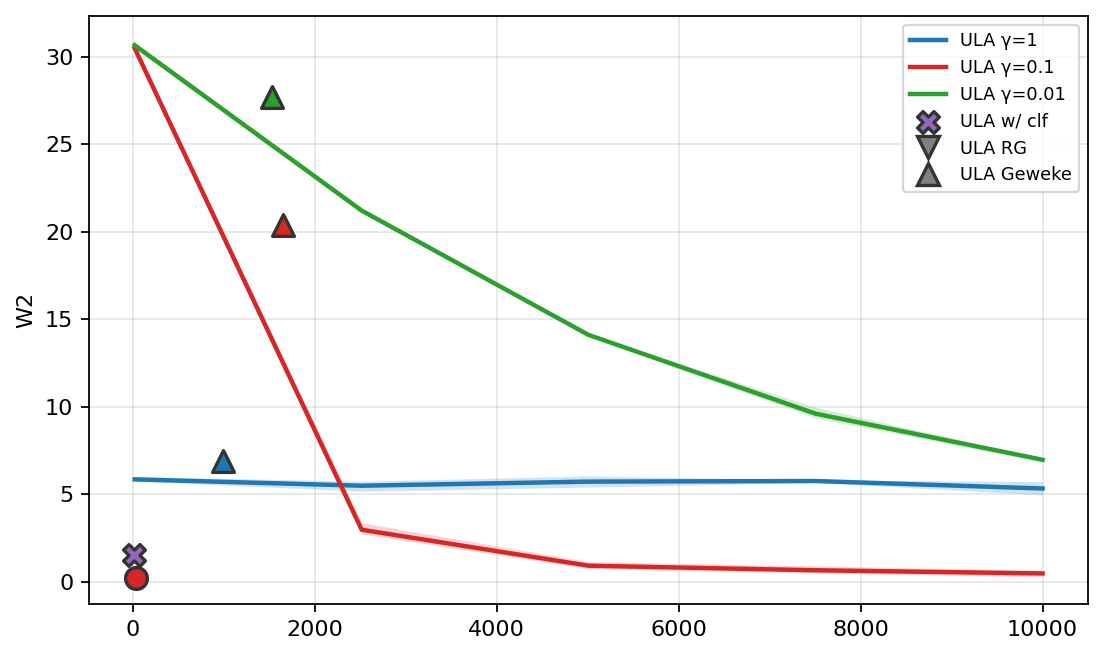

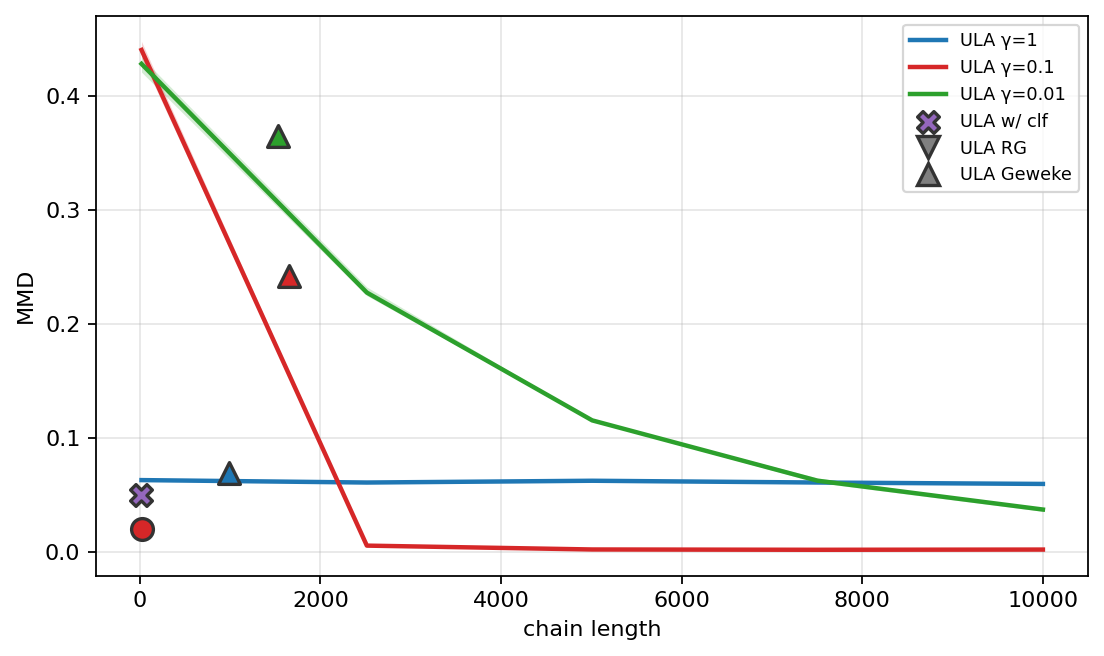

In [13]:
def _xerr_yerr(xy, x_ci, y_ci):
    """Match `gfn_non_acyclic_baseline_diagnostics._xerr_yerr`."""
    x, y = xy

    def _err(val, ci):
        if ci is None or not np.isfinite(val) or not np.all(np.isfinite(ci)):
            return None
        lo, hi = ci
        return np.asarray([[max(val - lo, 0.0)], [max(hi - val, 0.0)]])

    return _err(x, x_ci), _err(y, y_ci)


def _draw_diag_dot(ax, x, y, color, label, x_ci, y_ci, marker, ci_above_marker=False):
    # All markers: same size, uniform dark gray stroke
    MARKER_SIZE = 96
    EDGE_COLOR = "#333333"
    EDGE_WIDTH = 1.5

    if x is None or y is None or not (np.isfinite(x) and np.isfinite(y)):
        return
    xerr, yerr = _xerr_yerr((x, y), x_ci, y_ci)

    if marker == "^" or ci_above_marker:
        # Triangle or requested: draw marker first, then errorbar (so errorbar overlays triangle)
        ax.scatter(
            [x], [y], color=color, marker=marker, s=MARKER_SIZE, label=label, zorder=3,
            edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH
        )
        # Optionally, add CIs if desired (commented out)
        # ax.errorbar(
        #     [x],
        #     [y],
        #     xerr=xerr,
        #     yerr=yerr,
        #     color=color,
        #     ecolor=EDGE_COLOR,
        #     label=None,
        #     fmt="none",
        #     capsize=2,
        #     elinewidth=1.0,
        #     zorder=4,
        # )
    else:
        # Normal mode: marker & CI drawn together, marker below CI (matplotlib default)
        pass
        # ax.errorbar(
        #     [x],
        #     [y],
        #     xerr=xerr,
        #     yerr=yerr,
        #     color=color,
        #     ecolor=EDGE_COLOR,
        #     label=label,
        #     fmt=marker,
        #     markersize=np.sqrt(MARKER_SIZE), # markersize is diameter in points squared
        #     markeredgewidth=EDGE_WIDTH,
        #     markeredgecolor=EDGE_COLOR,
        #     capsize=2,
        #     elinewidth=1.0,
        #     zorder=1,
        # )


def _add_reference_markers(ax, ref, y_key: str):
    MARKER_SIZE = 96
    EDGE_COLOR = "#333333"
    EDGE_WIDTH = 1.5
    if not ref:
        return
    uc = ref.get("ula_clf")
    if uc and uc.get("mtl") is not None and uc.get(y_key) is not None:
        ax.scatter(
            [uc["mtl"]],
            [uc[y_key]],
            c="#9467bd",
            s=MARKER_SIZE,
            marker="X",
            zorder=4,
            label="ULA w/ clf",
            edgecolor=EDGE_COLOR,
            linewidth=EDGE_WIDTH,
        )
    fm = ref.get("full_model")
    if fm and fm.get("mtl") is not None and fm.get(y_key) is not None:
        ax.scatter(
            [fm["mtl"]],
            [fm[y_key]],
            c="#d62728",
            s=MARKER_SIZE,
            marker="o",
            zorder=4,
            label="Full model",
            edgecolor=EDGE_COLOR,
            linewidth=EDGE_WIDTH,
        )


from matplotlib.lines import Line2D

_GAMMA_PALETTE = ("#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#8c564b", "#17becf")


def _format_g(g):
    return f"{float(g):g}"


_ref = REFERENCE_METRICS.get((_name, _dim))
results = ula_plot_data
single = len(results) == 1
has_mmd = results[0]["mmd_mean"] is not None

# --- SD Plot ---
fig_sd, ax_sd = plt.subplots(figsize=(7, 4.2), dpi=160)

for i, D in enumerate(results):
    g = D["gamma"]
    tg = D["t_grid"]
    rh = D["rhat"]
    if single:
        line_c = "gold"
        rhat_c, gew_c = "#2ca02c", "#ff7f0e"
        line_lab = "ULA"
        rhat_lab, gew_lab = "ULA RG", "ULA Geweke"
    else:
        line_c = rhat_c = gew_c = _GAMMA_PALETTE[i % len(_GAMMA_PALETTE)]
        line_lab = f"ULA γ={_format_g(g)}"
        rhat_lab, gew_lab = None, None  # Only put line_lab in legend
    ax_sd.plot(tg, D["sd_mean"], color=line_c, lw=2.0, label=line_lab)
    ax_sd.fill_between(tg, D["sd_ci_lo"], D["sd_ci_hi"], color=line_c, alpha=0.2, linewidth=0)
    _draw_diag_dot(ax_sd, rh["t"], rh["sd"], rhat_c, rhat_lab, rh["t_ci"], rh["sd_ci"], "v")
    if D["geweke"] is not None:
        g0 = D["geweke"]
        _draw_diag_dot(ax_sd, g0["t"], g0["sd"], gew_c, gew_lab, g0["t_ci"], g0["sd_ci"], "^", ci_above_marker=True)

_add_reference_markers(ax_sd, _ref, "sd")
ax_sd.set_ylabel("W2")
ax_sd.grid(alpha=0.3)

# Legend setup for SD plot
MARKER_SIZE = 96
EDGE_COLOR = "#333333"
EDGE_WIDTH = 1.5
shape_proxies_sd = (
    []
    if single
    else [
        Line2D([], [], linestyle="none", marker="v", color="gray", markersize=np.sqrt(MARKER_SIZE), label="ULA RG",
               markeredgewidth=EDGE_WIDTH, markeredgecolor=EDGE_COLOR),
        Line2D([], [], linestyle="none", marker="^", color="gray", markersize=np.sqrt(MARKER_SIZE), label="ULA Geweke",
               markeredgewidth=EDGE_WIDTH, markeredgecolor=EDGE_COLOR),
    ]
)
h0, l0 = ax_sd.get_legend_handles_labels()
def is_sd_label(lab):
    return lab is not None and (lab.startswith("ULA") or lab == "ULA")
h0_sd = [h for h, lab in zip(h0, l0) if is_sd_label(lab)]
l0_sd = [lab for lab in l0 if is_sd_label(lab)]
ax_sd.legend(
    h0_sd + shape_proxies_sd,
    l0_sd + [p.get_label() for p in shape_proxies_sd],
    loc="best",
    fontsize=8,
)

fig_sd.tight_layout()
plt.show()

# --- MMD Plot (if available) ---
if has_mmd:
    fig_mmd, ax_mmd = plt.subplots(figsize=(7, 4.2), dpi=160)
    for i, D in enumerate(results):
        g = D["gamma"]
        tg = D["t_grid"]
        rh = D["rhat"]
        if single:
            line_c = "gold"
            rhat_c, gew_c = "#2ca02c", "#ff7f0e"
            line_lab = "ULA"
        else:
            line_c = rhat_c = gew_c = _GAMMA_PALETTE[i % len(_GAMMA_PALETTE)]
            line_lab = f"ULA γ={_format_g(g)}"
        ax_mmd.plot(tg, D["mmd_mean"], color=line_c, lw=2.0, label=line_lab)
        ax_mmd.fill_between(tg, D["mmd_ci_lo"], D["mmd_ci_hi"], color=line_c, alpha=0.2, linewidth=0)
        _draw_diag_dot(ax_mmd, rh["t"], rh["mmd"], rhat_c, None, rh["t_ci"], rh["mmd_ci"], "v")
        if D["geweke"] is not None and "mmd" in D["geweke"]:
            g1 = D["geweke"]
            _draw_diag_dot(ax_mmd, g1["t"], g1["mmd"], gew_c, None, g1["t_ci"], g1["mmd_ci"], "^", ci_above_marker=True)
    _add_reference_markers(ax_mmd, _ref, "mmd")
    ax_mmd.set_xlabel("chain length")
    ax_mmd.set_ylabel("MMD")
    ax_mmd.grid(alpha=0.3)

    shape_proxies_mmd = (
        []
        if single
        else [
            Line2D([], [], linestyle="none", marker="v", color="gray", markersize=np.sqrt(MARKER_SIZE), label="ULA RG",
                   markeredgewidth=EDGE_WIDTH, markeredgecolor=EDGE_COLOR),
            Line2D([], [], linestyle="none", marker="^", color="gray", markersize=np.sqrt(MARKER_SIZE), label="ULA Geweke",
                   markeredgewidth=EDGE_WIDTH, markeredgecolor=EDGE_COLOR),
        ]
    )
    h1, l1 = ax_mmd.get_legend_handles_labels()
    def is_mmd_label(lab):
        return lab is not None and (lab.startswith("ULA") or lab == "ULA")
    h1_mmd = [h for h, lab in zip(h1, l1) if is_mmd_label(lab)]
    l1_mmd = [lab for lab in l1 if is_mmd_label(lab)]
    ax_mmd.legend(
        h1_mmd + shape_proxies_mmd,
        l1_mmd + [p.get_label() for p in shape_proxies_mmd],
        loc="best",
        fontsize=8,
    )

    fig_mmd.tight_layout()
    plt.show()